# Постановка задачи

Целью данного этапа является построение модели для предсказания значения CC50.

Параметр CC50 характеризует токсичность соединения, поэтому задача формулируется как задача регрессии.

Как и в случае с IC50, для анализа используется логарифмическое преобразование целевой переменной, поскольку EDA показал наличие сильной асимметрии и выбросов.

# Импорты

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Загрузка данных

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


# Подготовка данных

In [3]:
target = "CC50, mM"

# логарифмируем таргет
y = np.log1p(df[target])

X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

В качестве целевой переменной используется логарифмированное значение CC50.

Признаки включают числовые характеристики соединений за исключением целевых переменных.

# Train/Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Baseline модель

В качестве baseline используется DummyRegressor, предсказывающий среднее значение целевой переменной.

Это позволяет оценить, насколько модели машинного обучения превосходят простую стратегию.

In [5]:
dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

# Функция метрик

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Метрики baseline модели

In [7]:
baseline_metrics = regression_metrics(
    y_test,
    y_pred_dummy
)

baseline_metrics

{'MAE': 1.2895160387503675,
 'RMSE': 1.5146319925068483,
 'R2': -0.008706671461702564}

# Сравнение моделей

Для решения задачи рассматриваются несколько моделей машинного обучения:
- линейные модели
- метод ближайших соседей
- ансамбли деревьев
- бустинговые методы

Это позволяет определить, какой тип алгоритмов лучше подходит для предсказания CC50.

In [8]:
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

In [9]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)
    metrics["model"] = name
    results.append(metrics)

In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")
results_df

,MAE,RMSE,R2,model
4,0.766801,1.121700,0.446772,ExtraTrees
3,0.821398,1.144972,0.423578,RandomForest
5,0.817717,1.145330,0.423218,GradientBoosting
6,0.825060,1.197189,0.369804,HistGradientBoosting
2,0.821953,1.203630,0.363004,KNN
0,0.937085,1.247745,0.315454,Ridge
1,1.289516,1.514632,-0.008707,Lasso


# График сравнения моделей

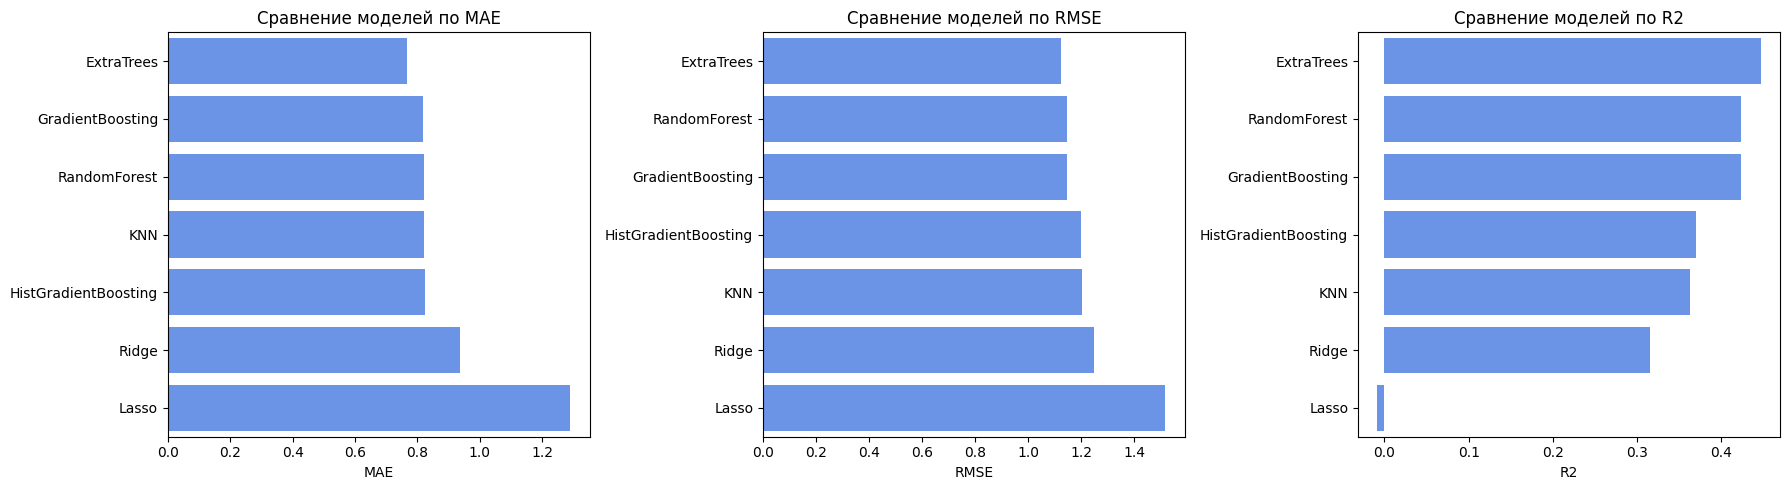

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics_names):
    sns.barplot(
        data=results_df.sort_values(
            metric,
            ascending=(metric != "R2")
        ),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(
        f"Сравнение моделей по {metric}"
    )

    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

По результатам сравнения моделей наилучшее качество показала модель ExtraTreesRegressor.

По сравнению с задачей предсказания IC50 качество моделей для CC50 оказалось немного выше, что может говорить о более устойчивых зависимостях между признаками и токсичностью соединений.

Как и в предыдущей задаче, ансамблевые методы значительно превосходят линейные модели, что подтверждает сложный нелинейный характер данных.

Модель ExtraTrees показала лучший результат среди ансамблей деревьев, что может быть связано с её устойчивостью к шуму и высокой случайностью построения деревьев.

# Эксперимент: логарифмирование признаков

На этапе EDA было выявлено наличие признаков с сильной асимметрией распределения.

Для проверки гипотезы о влиянии распределения признаков на качество модели дополнительно рассмотрим вариант с логарифмированием признаков.

In [12]:
X_log = X.copy()

skewness = X_log.skew()

high_skew_cols = skewness[skewness.abs() > 2].index

for col in high_skew_cols:
    if (X_log[col] >= 0).all(): X_log[col] = np.log1p(X_log[col])

In [13]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
results_log = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train_log, y_train_log)

    y_pred = pipe.predict(X_test_log)

    metrics = regression_metrics(y_test_log, y_pred)

    metrics["model"] = name

    results_log.append(metrics)

In [15]:
results_df_log = pd.DataFrame(results_log)

results_df_log = results_df_log.sort_values("RMSE")

results_df_log

,MAE,RMSE,R2,model
4,0.766817,1.132247,0.436320,ExtraTrees
5,0.816946,1.144862,0.423689,GradientBoosting
3,0.818241,1.145129,0.423420,RandomForest
6,0.820900,1.187544,0.379917,HistGradientBoosting
2,0.844123,1.203596,0.363040,KNN
0,0.929829,1.221064,0.344417,Ridge
1,1.289516,1.514632,-0.008707,Lasso


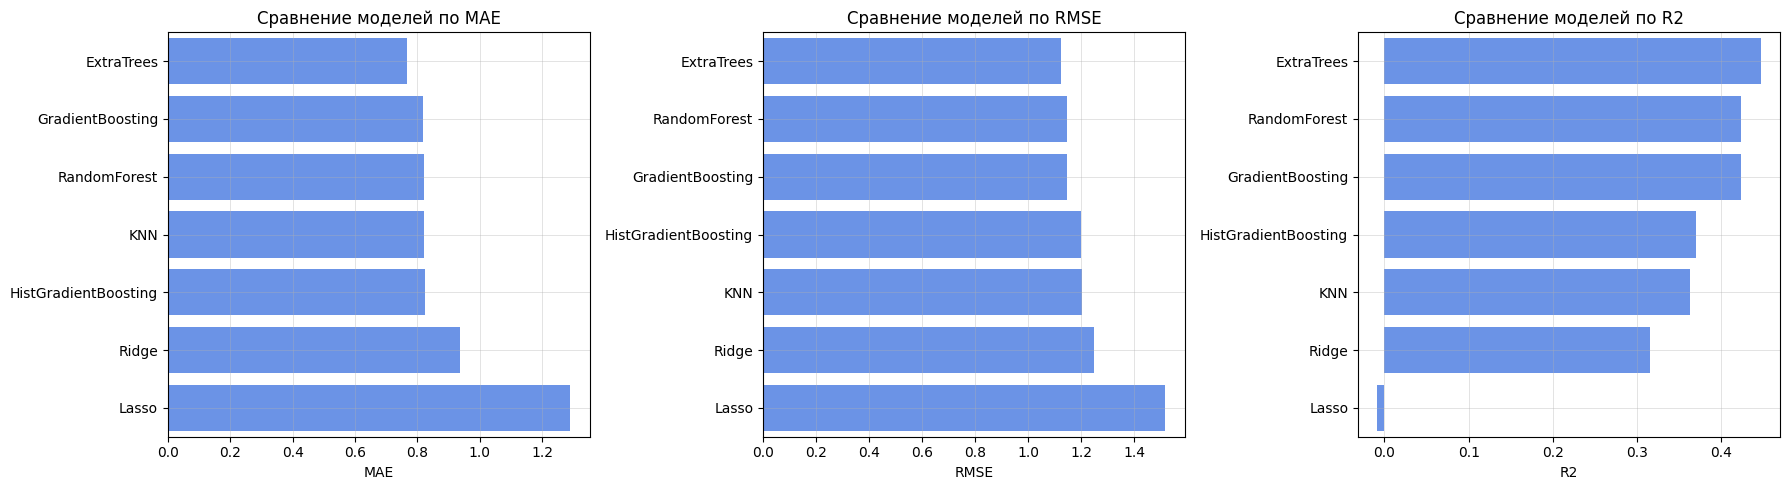

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics_names):
    sns.barplot(
        data=results_df.sort_values(metric, ascending=(metric != "R2")),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

Логарифмирование признаков не привело к заметному улучшению качества моделей.

Это говорит о том, что для задачи предсказания CC50 достаточно использовать масштабирование признаков и логарифмирование целевой переменной.

# Подбор гиперпараметров
После первичного сравнения моделей выполним подбор гиперпараметров для модели ExtraTreesRegressor, показавшей наилучший результат.

In [17]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [18]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("model", ExtraTreesRegressor(random_state=42))
])

In [19]:
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [20]:
best_model = grid.best_estimator_

grid.best_params_

{'model__max_depth': 10,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 10,
 'model__n_estimators': 200}

In [21]:
y_pred = best_model.predict(X_test)

best_metrics = regression_metrics(y_test, y_pred)

best_metrics

{'MAE': 0.7867106998274007,
 'RMSE': 1.0958377483348718,
 'R2': 0.471988776041804}

Подбор гиперпараметров позволил дополнительно улучшить качество модели за счёт более удачного выбора глубины деревьев и количества оценщиков.

# Анализ качества модели

Для более детального анализа рассмотрим визуализации предсказаний и ошибок модели.

Это позволит оценить:
- насколько хорошо модель предсказывает реальные значения
- есть ли систематические ошибки
- на каких объектах модель работает хуже

## True vs Predicted

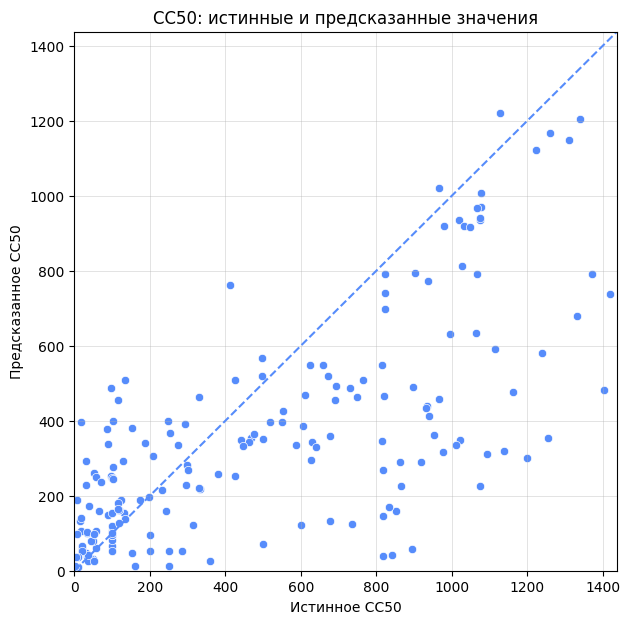

In [22]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

limit = np.percentile(np.concatenate([y_test_real, y_pred_real]), 95)

plt.figure(figsize=(7, 7))

sns.scatterplot(x=y_test_real, y=y_pred_real)

plt.plot([0, limit], [0, limit], linestyle="--")

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Истинное CC50")
plt.ylabel("Предсказанное CC50")

plt.title("CC50: истинные и предсказанные значения")

plt.grid()
plt.show()

График показывает, что модель улавливает общую зависимость между признаками и значением CC50.

Для основной массы объектов предсказания располагаются относительно близко к диагонали, что говорит о достаточно стабильном качестве модели.

При этом для больших значений CC50 наблюдается заметное занижение предсказаний, что связано с наличием редких экстремальных значений в данных.

## Ошибки модели

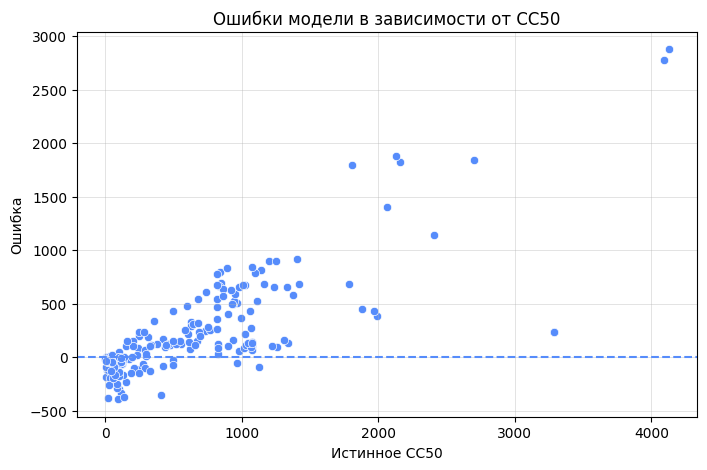

In [23]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test_real, y=residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Истинное CC50")
plt.ylabel("Ошибка")

plt.title("Ошибки модели в зависимости от CC50")

plt.grid()

plt.show()

График ошибок показывает, что для основной массы объектов ошибки модели остаются относительно небольшими.

Однако при увеличении значения CC50 разброс ошибок начинает быстро возрастать. При этом модель чаще занижает большие значения CC50.

Подобное поведение связано с тем, что экстремальные значения представлены в данных значительно реже, поэтому модель имеет меньше примеров для обучения на таких объектах.

# Важность признаков

In [24]:
model = best_model.named_steps["model"]

feature_names = X.columns

if "variance" in best_model.named_steps:
    mask = best_model.named_steps["variance"].get_support()
    feature_names = feature_names[mask]

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importances = importances.sort_values(
    "importance",
    ascending=False
).head(15)

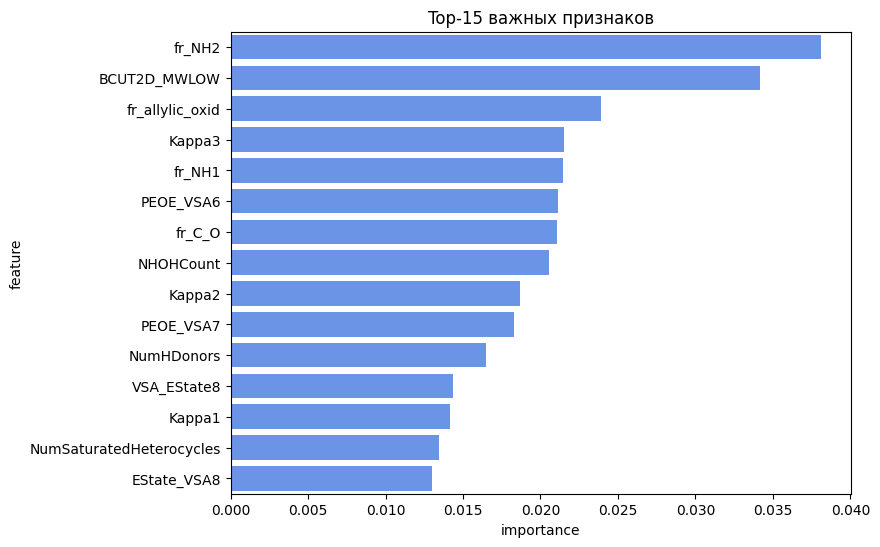

In [25]:
plt.figure(figsize=(8, 6))

sns.barplot(data=importances, x="importance", y="feature")

plt.title("Top-15 важных признаков")

plt.show()

Анализ важности признаков показывает, что модель использует сразу несколько характеристик соединений для предсказания CC50.

Наиболее важными оказались признаки, связанные с химической структурой и функциональными группами молекул, например fr_NH2, NHOHCount и NumHDonors.

По сравнению с задачей предсказания IC50 набор наиболее важных признаков заметно отличается. Это может говорить о том, что токсичность и противовирусная активность определяются различными свойствами соединений.

Важно отметить, что высокая importance не означает причинно-следственную связь, а лишь показывает значимость признака для предсказания внутри модели.

# Выводы

В рамках задачи была построена модель для предсказания значения CC50, характеризующего токсичность химических соединений.

Перед обучением моделей была выполнена подготовка данных:
- пропущенные значения заменялись медианой
- удалялись признаки с нулевой дисперсией
- использовалось масштабирование признаков
- для целевой переменной применялось логарифмическое преобразование

Сравнение моделей показало, что наилучшее качество демонстрируют ансамблевые методы, особенно ExtraTreesRegressor. Линейные модели показали значительно более низкое качество, что подтверждает сложный нелинейный характер зависимости CC50 от химических характеристик соединений.

По сравнению с задачей предсказания IC50 качество моделей для CC50 оказалось немного выше. Это может говорить о более устойчивых зависимостях между признаками и токсичностью соединений.

Дополнительный эксперимент с логарифмированием признаков не привёл к существенному улучшению качества моделей, поэтому в качестве основного варианта подготовки данных использовалось только логарифмирование целевой переменной.

Анализ визуализаций показал, что модель достаточно хорошо улавливает общую зависимость между признаками и значением CC50. Для основной массы объектов предсказания располагаются относительно близко к диагонали, однако при увеличении значения CC50 ошибки модели начинают возрастать.

Наибольшие ошибки возникают для редких экстремальных значений CC50, которые значительно реже представлены в обучающей выборке. При этом модель чаще занижает большие значения CC50.

Анализ важности признаков показал, что для предсказания CC50 модель использует признаки, связанные с химической структурой и функциональными группами молекул. По сравнению с задачей предсказания IC50 набор наиболее важных признаков заметно отличается, что может говорить о различной природе токсичности и противовирусной активности соединений.

Таким образом, для задачи предсказания CC50 наиболее эффективными оказались ансамблевые методы, способные учитывать сложные нелинейные зависимости и устойчиво работать на данных с выбросами и асимметричным распределением.